In [1]:
#Imports e Conexão
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sqlalchemy import create_engine

engine = create_engine(
    f"mysql+pymysql://{os.environ['DB_USER']}:{os.environ['DB_PASS']}@{os.environ['DB_HOST']}/{os.environ['DB_NAME']}"
)

In [2]:
# Q1: Os 10 produtos mais caros ordenados por preço
pd.read_sql("""
    SELECT *
    FROM data_product
    ORDER BY PRODUCT_VAL DESC
    LIMIT 10
""", engine)

,PRODUCT_COD,PRODUCT_NAME,PRODUCT_VAL,DEP_NAME,DEP_COD,SECTION_NAME,SECTION_COD
0,301409,Whisky Escoces THE MACALLAN Ruby Garrafa 700ml...,741.99,BEBIDAS,2,BEBIDAS,4
1,176185,Whisky Escoces JOHNNIE WALKER Blue Label Garra...,735.90,BEBIDAS,2,BEBIDAS,4
2,315481,Cafeteira Expresso 3 CORACOES Tres Modo Vermelho,499.00,BEBIDAS,2,BEBIDAS,4
3,100280,Vinho Portugues Tinto Vintage QUINTA DO CRASTO...,445.90,BEBIDAS,2,VINHOS,30
4,320046,Escova Dental Eletrica ORAL B D34 Professional...,399.90,PERFUMARIA,8,HIGIENE BUCAL,39
5,190817,Champagne Rose VEUVE CLICQUOT PONSARDIM Garraf...,366.90,MERCEARIA,6,ARTIGOS-PARA-O-LAR,2
6,153795,Champagne Frances Brut Imperial MOET Rose Garr...,359.90,MERCEARIA,6,ARTIGOS-PARA-O-LAR,2
7,311397,Conjunto de Panelas Allegra em Inox TRAMONTINA...,359.00,MERCEARIA,6,ARTIGOS-PARA-O-LAR,2
8,147706,Whisky Escoces CHIVAS REGAL 18 Anos Garrafa 750ml,329.90,BEBIDAS,2,BEBIDAS,4
9,154431,Champagne Frances Brut Imperial MOET & CHANDON...,315.90,MERCEARIA,6,ARTIGOS-PARA-O-LAR,2


In [3]:
# Q2: Seções únicas dos departamentos BEBIDAS e PADARIA
pd.read_sql("""
    SELECT DISTINCT SECTION_NAME
    FROM data_product
    WHERE DEP_NAME IN ('BEBIDAS', 'PADARIA')
""", engine)

,SECTION_NAME
0,BEBIDAS
1,VINHOS
2,DOCES-E-SOBREMESAS
3,QUEIJOS-E-FRIOS
4,CERVEJAS
5,PADARIA
6,REFRESCOS
7,GESTANTE


In [4]:
# Q3: Total de vendas agrupado por área de negócio no Q1 2019
pd.read_sql("""
    SELECT BUSINESS_NAME,
    SUM(SALES_VALUE) AS TOTAL_SALES
    FROM data_store_sales s
    JOIN data_store_cad c
    ON s.STORE_CODE = c.STORE_CODE
    WHERE s.DATE BETWEEN '2019-01-01' AND '2019-03-31'
    GROUP BY BUSINESS_NAME
    ORDER BY TOTAL_SALES DESC
""", engine)

,BUSINESS_NAME,TOTAL_SALES
0,Farma,81776691.73
1,Varejo,81032347.65
2,Atacado,80384884.60
3,Proximidade,80171122.80
4,Posto,32072326.40


In [5]:
# Case 1: Função dinâmica que aceita filtros opcionais
def retrieve_data(product_code=None, store_code=None, date=None):
    query = "SELECT * FROM data_product_sales WHERE 1=1"
    if product_code is not None:
        query += f" AND PRODUCT_CODE = {product_code}"
    if store_code is not None:
        query += f" AND STORE_CODE = '{store_code}'"
    if date is not None:
        query += f" AND DATE BETWEEN '{date[0]}' AND '{date[1]}'"
    return pd.read_sql(query, engine)

# Teste
my_data = retrieve_data(date=['2019-01-01', '2019-01-31'])
my_data.head()

,STORE_CODE,PRODUCT_CODE,DATE,SALES_VALUE,SALES_QTY
0,1,18,2019-01-01,708.5,65.0
1,1,18,2019-01-02,1297.1,119.0
2,1,18,2019-01-03,1144.5,105.0
3,1,18,2019-01-04,1090.0,100.0
4,1,18,2019-01-05,893.8,82.0


,Loja,Categoria,TM
0,Bahia,Atacado,15.39
1,Bangkok,Posto,13.67
2,Belem,Proximidade,15.37
3,Berlin,Proximidade,15.39
4,Buenos Aires,Atacado,15.39
5,Chicago,Varejo,15.53
6,Dubai,Atacado,15.39
7,Hong Kong,Farma,26.35
8,London,Farma,28.99
9,Madri,Farma,29.03


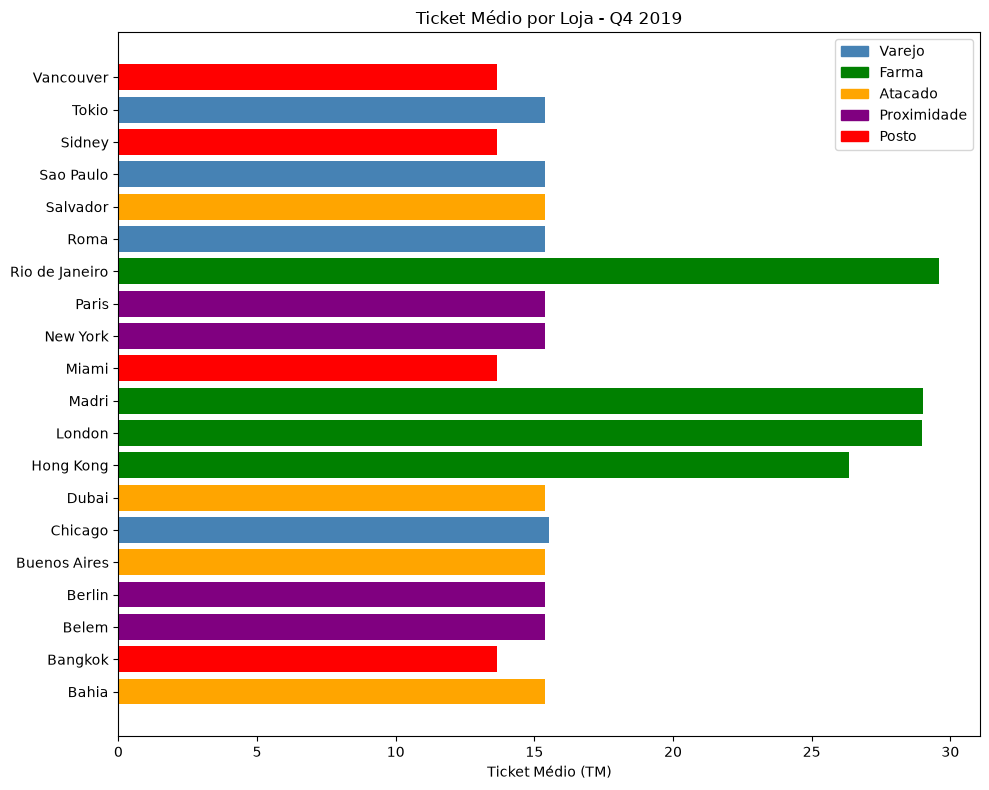

In [6]:
# Case 2: JOIN no Python + Ticket Médio por loja no Q4 2019
query1 = pd.read_sql("""
    SELECT STORE_CODE, STORE_NAME, START_DATE, END_DATE, BUSINESS_NAME, BUSINESS_CODE
    FROM data_store_cad
""", engine)

query2 = pd.read_sql("""
    SELECT STORE_CODE, DATE, SALES_VALUE, SALES_QTY
    FROM data_store_sales
    WHERE DATE BETWEEN '2019-01-01' AND '2019-12-31'
""", engine)

merged = query1.merge(query2, on='STORE_CODE')
merged['DATE'] = pd.to_datetime(merged['DATE'])
filtered = merged[(merged['DATE'] >= '2019-10-01') & (merged['DATE'] <= '2019-12-31')]

resultado = filtered.groupby(['STORE_NAME', 'BUSINESS_NAME']).apply(
    lambda x: (x['SALES_VALUE'].sum() / x['SALES_QTY'].sum()), include_groups=False
).reset_index()

resultado.columns = ['Loja', 'Categoria', 'TM']
resultado['TM'] = resultado['TM'].round(2)
resultado = resultado.sort_values('Loja').reset_index(drop=True)

display(resultado)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 8))
colors = {'Varejo': 'steelblue', 'Farma': 'green', 'Atacado': 'orange', 
          'Proximidade': 'purple', 'Posto': 'red'}
ax.barh(resultado['Loja'], resultado['TM'], 
        color=[colors[cat] for cat in resultado['Categoria']])
ax.set_xlabel('Ticket Médio (TM)')
ax.set_title('Ticket Médio por Loja - Q4 2019')
legend = [Patch(color=v, label=k) for k, v in colors.items()]
ax.legend(handles=legend)
plt.tight_layout()
plt.show()

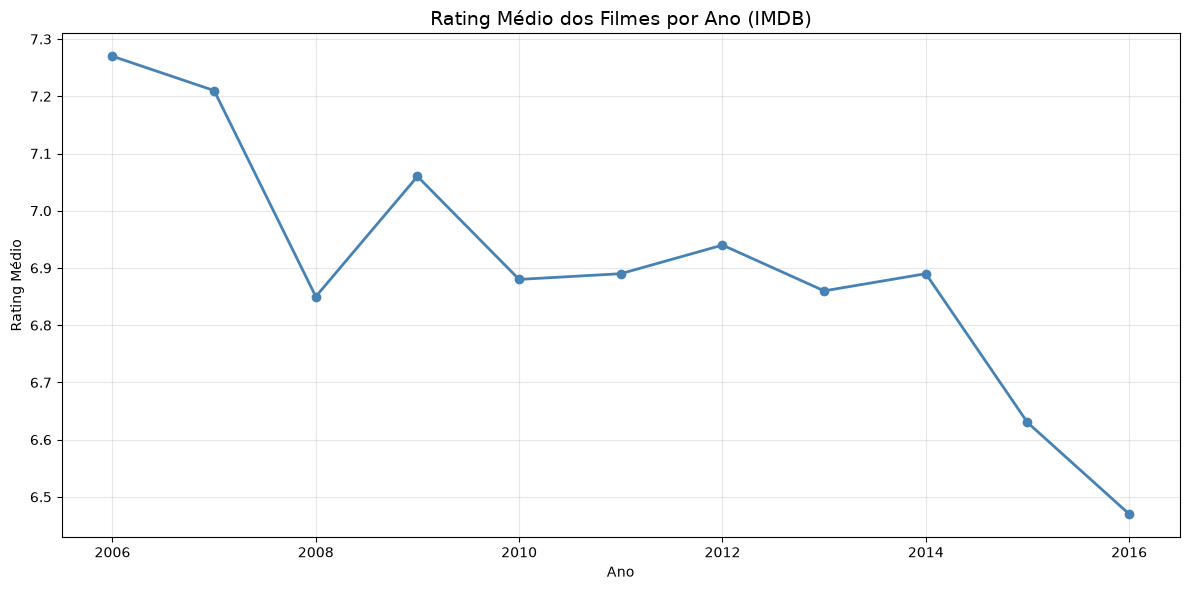

In [7]:
# Case 3: Rating médio por ano mostra queda na qualidade dos filmes ao longo do tempo
df_imdb = pd.read_sql("SELECT Year, Rating FROM IMDB_movies WHERE Year IS NOT NULL AND Rating IS NOT NULL", engine)

rating_por_ano = df_imdb.groupby('Year')['Rating'].mean().reset_index()
rating_por_ano.columns = ['Ano', 'Rating Médio']
rating_por_ano['Rating Médio'] = rating_por_ano['Rating Médio'].round(2)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(rating_por_ano['Ano'], rating_por_ano['Rating Médio'], 
        marker='o', color='steelblue', linewidth=2)
ax.set_title('Rating Médio dos Filmes por Ano (IMDB)', fontsize=14)
ax.set_xlabel('Ano')
ax.set_ylabel('Rating Médio')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()